In [1]:
import pandas as pd

df = pd.read_csv('Combined_Data.csv')

df = df[['statement', 'status']].dropna()

print(df.shape)
print(df['status'].value_counts())
print(df['statement'].iloc[0])

(52681, 2)
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64
oh my gosh


In [2]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                     # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)              # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                    # remove punctuation/numbers
    text = ' '.join(word for word in text.split() 
                    if word not in stop_words)              # remove stopwords
    return text

df['cleaned'] = df['statement'].apply(clean_text)

print(df[['statement', 'cleaned']].head(3))

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   

                                             cleaned  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label'] 
)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)   # fit only on train
X_test_tfidf = tfidf.transform(X_test)         # transform test (no fit)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

Label mapping:
  0 → Anxiety
  1 → Bipolar
  2 → Depression
  3 → Normal
  4 → Personality disorder
  5 → Stress
  6 → Suicidal

Train size: 42144, Test size: 10537
TF-IDF matrix shape: (42144, 10000)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Model 2: Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== Logistic Regression ===
                      precision    recall  f1-score   support

             Anxiety       0.78      0.81      0.79       768
             Bipolar       0.75      0.81      0.78       556
          Depression       0.79      0.63      0.70      3081
              Normal       0.88      0.91      0.89      3269
Personality disorder       0.52      0.77      0.62       215
              Stress       0.50      0.67      0.57       517
            Suicidal       0.66      0.72      0.69      2131

            accuracy                           0.76     10537
           macro avg       0.70      0.76      0.72     10537
        weighted avg       0.77      0.76      0.76     10537

=== Naive Bayes ===
                      precision    recall  f1-score   support

             Anxiety       0.83      0.56      0.67       768
             Bipolar       0.94      0.40      0.56       556
          Depression       0.49      0.84      0.62      3081
              Norm

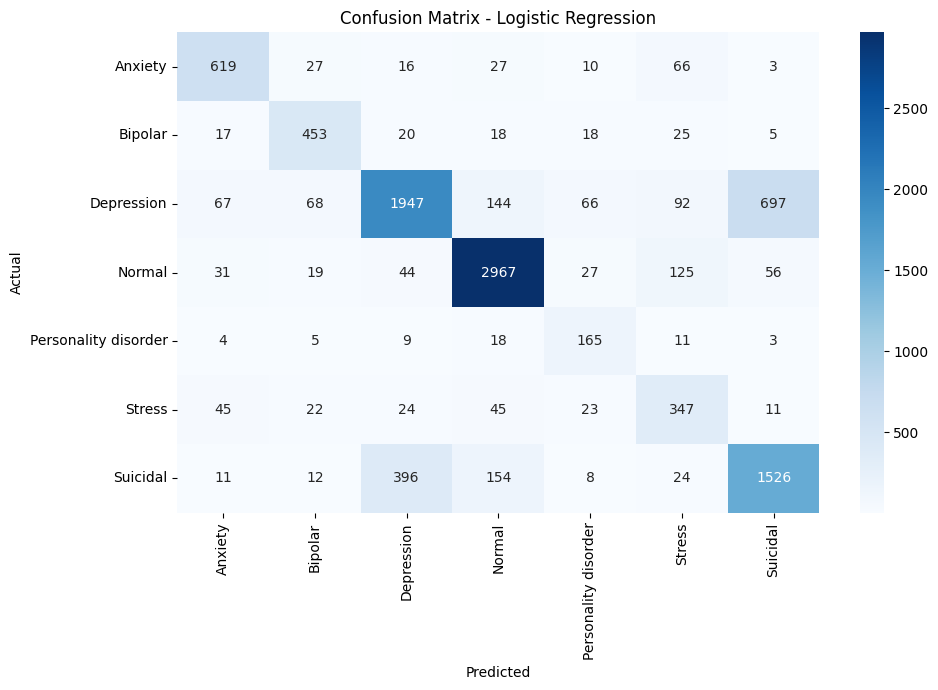

Normal
Anxiety


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix for Logistic Regression (the better model)
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_, 
            cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Predict function
def predict_mental_health(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr.predict(vectorized)[0]
    return le.inverse_transform([prediction])[0]

# Test it
print(predict_mental_health("Today was a great day, feeling really good"))
print(predict_mental_health("I've been feeling very anxious and nervous lately"))